In [ ]:
import os

base = "/kaggle/input"

for root, dirs, files in os.walk(base):
    print(root)

In [1]:
import os

train_path = "/kaggle/input/datasets/trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours/Video Dataset for Safe and Unsafe Behaviours/Safe and Unsafe Behaviours Dataset/train"

for folder in os.listdir(train_path):

    folder_path = os.path.join(train_path, folder)

    if os.path.isdir(folder_path):

        count = len(os.listdir(folder_path))

        print(folder, count)

4_safe_walkway 50
2_opened_panel cover 129
3_carrying_overload_with_forklift 48
6_closed_panel_cover 19
5_authorized_intervention 23
1_unauthorized_intervention 97
7_safe_carrying 22
0_safe_walkway_violation 178


In [2]:
import os

base_output = "/kaggle/working/small_dataset"

os.makedirs(f"{base_output}/safe", exist_ok=True)

os.makedirs(f"{base_output}/unsafe", exist_ok=True)

print("Folders created")

Folders created


In [4]:
import os
import random
import shutil

train_path = "/kaggle/input/datasets/trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours/Video Dataset for Safe and Unsafe Behaviours/Safe and Unsafe Behaviours Dataset/train"

output_path = "/kaggle/working/small_dataset"

safe_classes = [
    "4_safe_walkway",
    "5_authorized_intervention",
    "6_closed_panel_cover",
    "7_safe_carrying"
]

unsafe_classes = [
    "0_safe_walkway_violation",
    "1_unauthorized_intervention",
    "2_opened_panel cover",
    "3_carrying_overload_with_forklift"
]

safe_videos = []
unsafe_videos = []

In [5]:
for cls in safe_classes:

    class_path = os.path.join(train_path, cls)

    for file in os.listdir(class_path):

        safe_videos.append(
            os.path.join(class_path, file)
        )


for cls in unsafe_classes:

    class_path = os.path.join(train_path, cls)

    for file in os.listdir(class_path):

        unsafe_videos.append(
            os.path.join(class_path, file)
        )

In [6]:
random.seed(42)

unsafe_videos = random.sample(unsafe_videos, 114)

In [8]:
for video in safe_videos:

    shutil.copy(
        video,
        f"{output_path}/safe"
    )

In [9]:
for video in unsafe_videos:

    shutil.copy(
        video,
        f"{output_path}/unsafe"
    )

print("Done")

Done


In [10]:
print(
    len(os.listdir("/kaggle/working/small_dataset/safe"))
)

print(
    len(os.listdir("/kaggle/working/small_dataset/unsafe"))
)

114
114


In [11]:
import os

image_base = "/kaggle/working/image_dataset"

os.makedirs(f"{image_base}/safe", exist_ok=True)

os.makedirs(f"{image_base}/unsafe", exist_ok=True)

print("Folders created")

Folders created


In [12]:
import os
import cv2

video_base = "/kaggle/working/small_dataset"

image_base = "/kaggle/working/image_dataset"

for label in ["safe", "unsafe"]:

    folder = os.path.join(video_base, label)

    videos = os.listdir(folder)

    for idx, video_name in enumerate(videos):

        video_path = os.path.join(folder, video_name)

        cap = cv2.VideoCapture(video_path)

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        if total_frames < 5:

            cap.release()
            continue

        frame_positions = []

        for i in range(5):

            position = int(
                i * total_frames / 5
            )

            frame_positions.append(position)

        for frame_num, position in enumerate(frame_positions):

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                position
            )

            success, frame = cap.read()

            if success:

                filename = (
                    f"{label}_{idx}_{frame_num}.jpg"
                )

                save_path = os.path.join(
                    image_base,
                    label,
                    filename
                )

                cv2.imwrite(
                    save_path,
                    frame
                )

        cap.release()

print("Extraction complete")

Extraction complete


In [13]:
print(
    len(
        os.listdir(
            "/kaggle/working/image_dataset/safe"
        )
    )
)

print(
    len(
        os.listdir(
            "/kaggle/working/image_dataset/unsafe"
        )
    )
)

570
570


(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

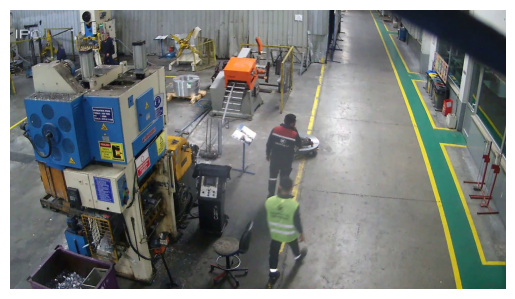

In [14]:
import matplotlib.pyplot as plt
import cv2

path = "/kaggle/working/image_dataset/safe"

sample = os.listdir(path)[0]

img = cv2.imread(
    os.path.join(path, sample)
)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.imshow(img)

plt.axis("off")

In [15]:
import os
import random
import shutil

source = "/kaggle/working/image_dataset"

destination = "/kaggle/working/final_dataset"

for split in ["train", "val"]:
    
    for label in ["safe", "unsafe"]:
        
        os.makedirs(
            os.path.join(destination, split, label),
            exist_ok=True
        )

random.seed(42)

for label in ["safe", "unsafe"]:
    
    images = os.listdir(
        os.path.join(source, label)
    )

    random.shuffle(images)

    split_index = int(
        len(images) * 0.8
    )

    train_images = images[:split_index]

    val_images = images[split_index:]

    for img in train_images:

        shutil.copy(
            os.path.join(source, label, img),

            os.path.join(
                destination,
                "train",
                label,
                img
            )
        )

    for img in val_images:

        shutil.copy(
            os.path.join(source, label, img),

            os.path.join(
                destination,
                "val",
                label,
                img
            )
        )

print("Done")

Done


In [16]:
for split in ["train","val"]:
    
    for label in ["safe","unsafe"]:
        
        count = len(
            os.listdir(
                f"/kaggle/working/final_dataset/{split}/{label}"
            )
        )

        print(split,label,count)

train safe 456
train unsafe 456
val safe 114
val unsafe 114


In [17]:
import torch

from torchvision import datasets

from torchvision import transforms

from torch.utils.data import DataLoader

In [18]:
transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()
])

In [19]:
train_dataset = datasets.ImageFolder(

    "/kaggle/working/final_dataset/train",

    transform=transform
)

val_dataset = datasets.ImageFolder(

    "/kaggle/working/final_dataset/val",

    transform=transform
)

In [20]:
train_loader = DataLoader(

    train_dataset,

    batch_size=16,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=16,

    shuffle=False
)

In [21]:
print(train_dataset.classes)

['safe', 'unsafe']


In [22]:
import torch.nn as nn

from torchvision.models import resnet18

In [24]:
model = resnet18(
    weights="DEFAULT"
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s] 


In [25]:
model.fc = nn.Linear(
    model.fc.in_features,

    2
)

In [26]:
device = torch.device("cpu")

model = model.to(device)

In [27]:
criterion = nn.CrossEntropyLoss()

In [28]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001
)

In [29]:
epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(
        f"Epoch {epoch+1}/{epochs}"
    )

    print(
        f"Loss: {running_loss:.4f}"
    )

    print(
        f"Train Accuracy: {accuracy:.2f}%"
    )

    print("-"*30)

Epoch 1/5
Loss: 41.2430
Train Accuracy: 64.36%
------------------------------
Epoch 2/5
Loss: 26.3786
Train Accuracy: 77.85%
------------------------------
Epoch 3/5
Loss: 24.8847
Train Accuracy: 79.50%
------------------------------
Epoch 4/5
Loss: 23.5882
Train Accuracy: 80.26%
------------------------------
Epoch 5/5
Loss: 20.5150
Train Accuracy: 84.21%
------------------------------


In [30]:
model.eval()

correct = 0

total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

val_accuracy = 100 * correct / total

print(
    f"Validation Accuracy: {val_accuracy:.2f}%"
)

Validation Accuracy: 80.70%


In [31]:
torch.save(
    model.state_dict(),
    "/kaggle/working/model.pth"
)

print("Model saved")

Model saved
